# Heat Equation PINN - Version 3 (Standard with Weight Decay / L2 Regularization)

This notebook implements a standard Physics-Informed Neural Network (PINN) to solve the 1D heat equation with L2 regularization (weight decay) applied to the optimizer. 

By adding a penalty based on the squared L2 norm of the network weights ($\lambda_r \sum_{l=1}^{L} \|W^{(l)}\|_2^2$), we penalize large weights. This regularizes the network parameters directly, keeping them small, which prevents overfitting and yields smoother solutions/derivatives.

The PDE residual loss is computed as:
$$\text{Loss}_{CLP} = \text{mean}((u_t - \alpha u_{xx})^2)$$

The total loss is:
$$\text{Loss} = \text{Loss}_{CLP} + \text{Loss}_{IC} + \text{Loss}_{BC}$$
with weight decay handled directly by the optimizer.

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

## 1. PINN Architecture Definition
Definition of the standard Neural Network (Multi-Layer Perceptron) to approximate the solution $u(t,x)$.

In [4]:
class PinnHeatEq(nn.Module):
    def __init__(self):
        super().__init__()
        self.couche_entree = nn.Linear(2, 50)
        self.couche_cachee1 = nn.Linear(50, 50)
        self.couche_cachee2 = nn.Linear(50, 50)
        self.couche_sortie = nn.Linear(50, 1)

    def forward(self, x):
        x = torch.tanh(self.couche_entree(x))
        x = torch.tanh(self.couche_cachee1(x))
        x = torch.tanh(self.couche_cachee2(x))
        return self.couche_sortie(x)

## 2. Sampling and Collocation Points Generation
Functions to generate collocation points (in the domain), initial points ($t=0$), and boundary points ($x=0$ and $x=1$).

In [5]:
t_min, t_max = 0.0, 1.0
x_min, x_max = 0.0, 1.0


def generer_points_collocation(n_pde):
    t_colloc = torch.rand(n_pde, 1) * (t_max - t_min) + t_min
    x_colloc = torch.rand(n_pde, 1) * (x_max - x_min) + x_min
    return t_colloc.float(), x_colloc.float()


def generer_points_initiaux(n_iv):
    t_init = torch.zeros(n_iv, 1)
    x_init = torch.rand(n_iv, 1) * (x_max - x_min) + x_min
    return t_init.float(), x_init.float()


def generer_points_bords(n_bords):
    t_bord = torch.rand(n_bords, 1) * (t_max - t_min) + t_min
    x_gauche = torch.ones(n_bords // 2, 1) * x_min
    x_droite = torch.ones(n_bords // 2, 1) * x_max
    x_bord = torch.cat([x_gauche, x_droite], dim=0)
    return t_bord.float(), x_bord.float()

## 3. Loss Functions Definition
Grouping of loss calculation functions for initial conditions (IV), boundary conditions (BC), and the PDE residual (CLP).

In [6]:
def calc_iv_loss(model, t_init, x_init, u_exact_init):
    u_pred = model(torch.cat([t_init, x_init], dim=1))
    return torch.mean((u_pred - u_exact_init) ** 2)


def calc_bc_loss(model, t_bord, x_bord, u_exact_bord):
    u_pred = model(torch.cat([t_bord, x_bord], dim=1))
    return torch.mean((u_pred - u_exact_bord) ** 2)


def calc_clp_loss(model, t_colloc, x_colloc, alpha):
    t_colloc.requires_grad_(True)
    x_colloc.requires_grad_(True)

    u_pred = model(torch.cat([t_colloc, x_colloc], dim=1))

    u_t = torch.autograd.grad(
        outputs=u_pred,
        inputs=t_colloc,
        grad_outputs=torch.ones_like(u_pred),
        create_graph=True,
    )[0]

    u_x = torch.autograd.grad(
        outputs=u_pred,
        inputs=x_colloc,
        grad_outputs=torch.ones_like(u_pred),
        create_graph=True,
    )[0]

    u_xx = torch.autograd.grad(
        outputs=u_x,
        inputs=x_colloc,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True,
    )[0]

    residu = u_t - alpha * u_xx
    return torch.mean(residu ** 2)

## 4. Hardware (Device), Model, and Optimizer Initialization
Hardware detection, model creation, and optimizer definition.

In [7]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(device)

alpha = 0.0005

modele = PinnHeatEq().to(device)
optimizer = optim.Adam(modele.parameters(), lr=0.001, weight_decay=1e-5)

t_colloc, x_colloc = generer_points_collocation(12000)
t_init, x_init = generer_points_initiaux(1000)
t_bord, x_bord = generer_points_bords(1000)

u_exact_init = torch.sin(2 * torch.pi * x_init)
u_exact_bord = torch.zeros_like(x_bord)

t_colloc, x_colloc = t_colloc.to(device), x_colloc.to(device)
t_init, x_init = t_init.to(device), x_init.to(device)
t_bord, x_bord = t_bord.to(device), x_bord.to(device)
u_exact_init = u_exact_init.to(device)
u_exact_bord = u_exact_bord.to(device)

mps


## 5. Model Training
Training phase of the PINN model using the defined optimizers (Adam and/or L-BFGS).

In [8]:
epochs = 12000

for epoch in range(epochs):
    optimizer.zero_grad()

    loss_iv = calc_iv_loss(modele, t_init, x_init, u_exact_init)
    loss_bc = calc_bc_loss(modele, t_bord, x_bord, u_exact_bord)
    loss_clp = calc_clp_loss(modele, t_colloc, x_colloc, alpha)

    loss_totale = 300 * loss_iv + 100 * loss_bc + loss_clp
    loss_totale.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoque {epoch:05d} | "
              f"Loss totale: {loss_totale.item():.2e} | "
              f"CLP: {loss_clp.item():.2e} | "
              f"BC: {loss_bc.item():.2e} | "
              f"IV: {loss_iv.item():.2e}")

Epoque 00000 | Loss totale: 154.288177 | CLP: 0.007811 | BC: 0.011795 | IV: 0.510336
Epoque 00100 | Loss totale: 82.279671 | CLP: 0.093284 | BC: 0.156185 | IV: 0.221893
Epoque 00200 | Loss totale: 13.035675 | CLP: 2.681203 | BC: 0.034193 | IV: 0.023117
Epoque 00300 | Loss totale: 1.854115 | CLP: 1.339272 | BC: 0.001081 | IV: 0.001356
Epoque 00400 | Loss totale: 0.698266 | CLP: 0.594141 | BC: 0.000182 | IV: 0.000286
Epoque 00500 | Loss totale: 0.350513 | CLP: 0.311696 | BC: 0.000092 | IV: 0.000099
Epoque 00600 | Loss totale: 0.207270 | CLP: 0.189670 | BC: 0.000053 | IV: 0.000041
Epoque 00700 | Loss totale: 0.139272 | CLP: 0.129730 | BC: 0.000036 | IV: 0.000020
Epoque 00800 | Loss totale: 0.136693 | CLP: 0.094870 | BC: 0.000097 | IV: 0.000107
Epoque 00900 | Loss totale: 0.080033 | CLP: 0.073913 | BC: 0.000024 | IV: 0.000012
Epoque 01000 | Loss totale: 0.117904 | CLP: 0.059617 | BC: 0.000121 | IV: 0.000154
Epoque 01100 | Loss totale: 0.054623 | CLP: 0.049988 | BC: 0.000019 | IV: 0.000009


## 6. Visualizing the Results
Comparison of the solution learned by the PINN with the exact analytical solution of the heat equation.

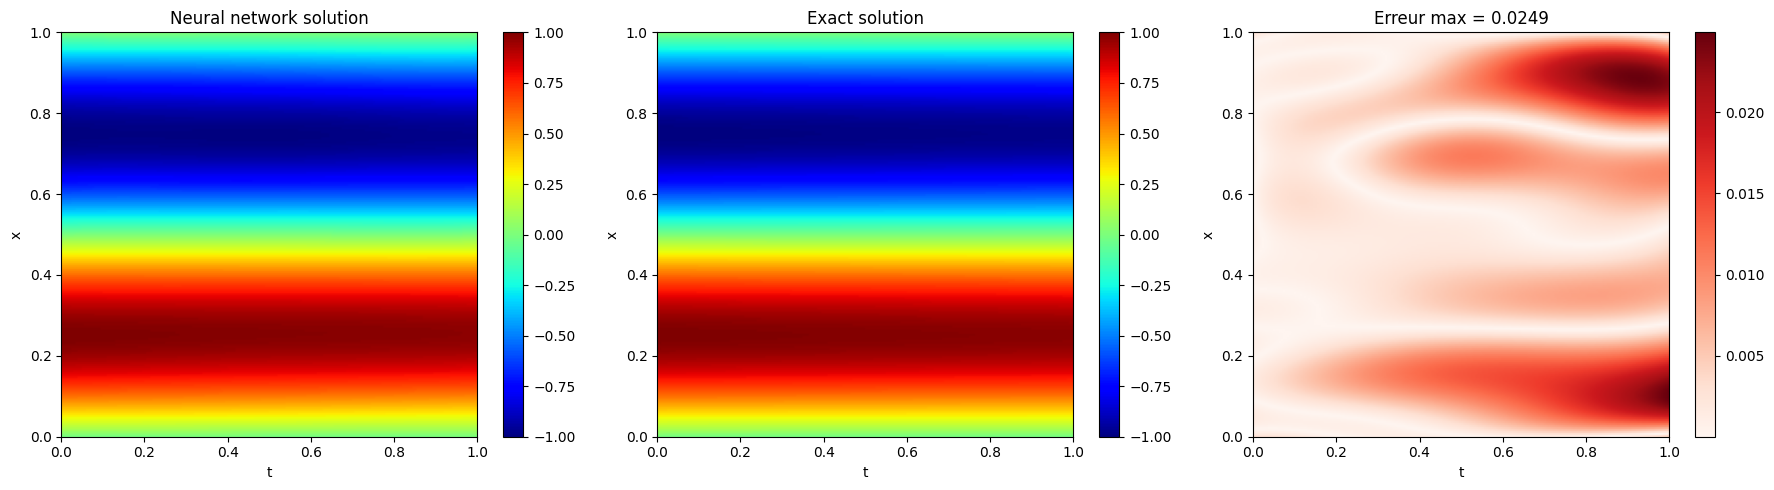

(array([[-0.00253452,  0.02994099,  0.06226035, ..., -0.06425892,
         -0.03332063, -0.0024475 ],
        [-0.00254066,  0.0299222 ,  0.06222928, ..., -0.06411019,
         -0.03315118, -0.00225731],
        [-0.00253966,  0.02990981,  0.0622046 , ..., -0.06396692,
         -0.03298823, -0.00207364],
        ...,
        [ 0.00358627,  0.03145169,  0.05948482, ..., -0.06077887,
         -0.03232348, -0.00397292],
        [ 0.00379427,  0.03162158,  0.05961767, ..., -0.06111538,
         -0.03266887, -0.00432688],
        [ 0.00400709,  0.03179549,  0.05975432, ..., -0.06146742,
         -0.03302926, -0.004696  ]], shape=(200, 200), dtype=float32),
 array([[ 0.00000000e+00,  3.15685498e-02,  6.31056313e-02, ...,
         -6.31056313e-02, -3.15685498e-02, -2.44929360e-16],
        [ 0.00000000e+00,  3.15654186e-02,  6.30993720e-02, ...,
         -6.30993720e-02, -3.15654186e-02, -2.44905066e-16],
        [ 0.00000000e+00,  3.15622877e-02,  6.30931134e-02, ...,
         -6.30931134e-0

In [9]:
import sys; sys.path.append("..")
import numpy as np                                                                                                    
from pinnplot import plot_solution                        

u_exact = lambda t, x: np.sin(2*np.pi*x) * np.exp(-(2*np.pi)**2 * alpha * t)

plot_solution(modele, u_exact)           
